
#**Introducción**
El presente proyecto se enfoca en el análisis de las exportaciones argentinas registradas entre los años 2015 y 2025, utilizando información oficial proveniente del portal gubernamental datos.gob.ar. Esta plataforma reúne datos públicos de distintos organismos del Estado, ofreciendo acceso abierto a información relevante para comprender fenómenos económicos, sociales y productivos del país.

El dataset seleccionado contiene registros detallados sobre los bienes exportados por Argentina, organizados por categorías que permiten explorar la estructura productiva nacional desde diferentes ángulos. Entre las variables disponibles se incluyen el año y mes de exportación, el valor en dólares, el peso neto de la mercadería, la provincia de origen, la región, y la clasificación del bien según rubro y tipo de producto. Esta organización posibilita un análisis rico y multidimensional del comportamiento exportador a lo largo del tiempo.

Uno de los puntos fuertes del dataset es la posibilidad de comprender qué se exporta, desde dónde se exporta y cuánto valor generan esas exportaciones. Al contar con información provincial y regional, se vuelve posible identificar cuáles zonas del país participan con mayor intensidad en el comercio internacional, qué sectores productivos impulsan las ventas externas y cómo han evolucionado las ganancias generadas por cada rubro.

Sin embargo, existen ciertas limitaciones inherentes al dataset. Entre ellas, la falta de información sobre los destinos internacionales de cada exportación o el origen extranjero de las empresas exportadoras. Esto restringe el análisis a una perspectiva interna: es decir, permite conocer la producción y el aporte económico desde Argentina, pero no habilita conclusiones sobre las relaciones bilaterales o el comercio con mercados específicos del exterior.

A partir de los datos disponibles, este proyecto busca responder preguntas clave como:

1. ¿Cuáles son los rubros y productos más exportados por Argentina durante el período analizado?

2. ¿Qué provincias y regiones concentran el mayor volumen exportador?

3. ¿En qué años y meses se registran los picos de exportación?

4. ¿Cómo evolucionaron las ganancias en dólares a lo largo del tiempo?

5. ¿Qué patrones o tendencias se pueden identificar en la distribución de los bienes exportados?

Como posibles respuestas podriamos pensar:

1. Es inevitable no focalizar la respuesta en el agro, principalmente en cultivos como la Soja y Cebada, tambien en la ganaderia con las carnes y sus derivados.

2. A primera vista, sin profundizar en datos empiricos, los exportadores que suelen destacarse en portales de noticias se centran en la Region Pampeana, con Buenos Aires y Cordoba a la cabeza, seguido quizas de la Region Cuyana con sus cultivos y derivados.

3. Teniendo nulo conocimiento sobre el agro y sus temporadas de siembre y cosecha, podria decir que exportan en los primeros meses del año, casi mediados del mismo. Febrero a Marzo.

4. Podria pensar que la pandemia pudo haber traido grandes ganancias debido al aumento de compras en general. Es un fenomeno digno de estudio.

5. Podriamos analizar patrones en relación a materias que no son de facil acceso para otros continentes, o bien por la riqueza del producto en si. Esto podria foicalizar las exportaciones en Materia Prima por las condiciones de nuestro país. Observandose una disminucion en los productos indrustrializados, como respuestos o maquinarias.

En resumen...

Este análisis no solo permite observar el desempeño económico general del país, sino también reconocer la importancia relativa de cada sector productivo y su aporte al desarrollo regional. En conjunto, los resultados ofrecerán una visión clara del perfil exportador argentino durante la última década, basada exclusivamente en datos medibles y verificables.

In [2]:
from IPython.display import HTML

HTML("""
<script>
code_show=true;
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
}
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()">
<input type="submit" value="Mostrar/Ocultar código">
</form>
""")

In [3]:
# Librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import calendar

# Configuración diseño global
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 14

# Carga del DataSet y filtros para trabajar con los datos necesarios
df = pd.read_excel('/content/Export_Arg_Mensual_2002_2025.xlsx')

from google.colab import drive
drive.mount('/content/drive')

# Limpieza de Datos

df.info()

# Conteo de valores nulos
nulos = df.isnull().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]
nulos

# Eliminamos registros sin información clave para el análisis
df = df.dropna(subset=['FOB_dólar', 'Rubro', 'tipo_Producto', 'Año'])

# Reemplazo de pesos nulos por 0 (si aplica)
df['Peso neto'] = df['Peso neto'].fillna(0)

# Revisión de duplicados
df = df.drop_duplicates()


Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26320 entries, 0 to 26319
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Año            26320 non-null  int64  
 1   Mes            26320 non-null  int64  
 2   FOB_dólar      26320 non-null  float64
 3   Peso neto      26320 non-null  float64
 4   Nombre Prov    26320 non-null  object 
 5   Nombre_Región  26320 non-null  object 
 6   Rubro          26320 non-null  object 
 7   tipo_Producto  26320 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 1.6+ MB


###**Evaluación de la calidad del dataset**

La inspección inicial del conjunto de datos indica que el dataset cuenta con 26.320 registros y 8 variables, sin presencia de valores nulos en ninguna de las columnas. Esto garantiza la integridad de la información y permite realizar los análisis sin necesidad de procesos de imputación o eliminación de observaciones.

Asimismo, las variables presentan tipos de datos adecuados para su análisis: variables numéricas para el valor FOB, el peso neto y el período temporal, y variables categóricas para la identificación de rubros, productos y regiones.

El bajo consumo de memoria del dataset facilita su manipulación y procesamiento, asegurando eficiencia computacional tanto para el análisis exploratorio como para la posterior implementación de modelos de aprendizaje automático.

In [4]:
# Funcion globalse

def formato_millones(x):
    if x >= 1_000_000_000:
        return f"{x/1_000_000_000:.2f} Mil millones"
    elif x >= 1_000_000:
        return f"{x/1_000_000:.2f} Millones"
    else:
        return f"{x:,.0f}"

def peso_legible(kg):
    if kg >= 1_000_000:
        return f"{kg/1_000_000:.2f} Tn."
    elif kg >= 1_000:
        return f"{kg/1_000:.2f} Kg."
    else:
        return f"{kg:.0f} Gr."

df = df[(df['Año'] >= 2015) & (df['Año'] <= 2025)]
df['Mes_nom'] = pd.Categorical(df['Mes'].apply(lambda x: calendar.month_name[x]))

# Filtros para gráficos

años = df['Año'].to_list()
rubros = df['Rubro'].to_list()
regiones = df['Nombre_Región'].to_list()
provincias = df['Nombre Prov'].to_list()
tipo = df['tipo_Producto'].to_list()


def filtrar(df, Año=None, Rubro=None, Region=None, Provincia=None):
    df_f = df.copy()

    if Año is not None:
        df_f = df_f[df_f['Año'].isin(años)]

    if Rubro is not None:
        df_f = df_f[df_f['Rubro'].isin(rubros)]

    if Region is not None:
        df_f = df_f[df_f['Nombre_Región'].isin(regiones)]

    if Provincia is not None:
        df_f = df_f[df_f['Nombre Prov'].isin(provincias)]

    return df_f

#Ejemplo para usarlo en un gráfico específico:
#df_filtro = filtrar(df, anio=[2020, 2021])

####**¿Cuáles son los rubros y productos más exportados por Argentina durante el período analizado?**
Esta sección busca identificar qué rubros y productos explican la mayor parte del valor exportado por Argentina durante el período analizado. Conocer esta composición permite entender el perfil exportador del país y evaluar el grado de concentración o diversificación de sus exportaciones.


/tmp/ipython-input-3381205909.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


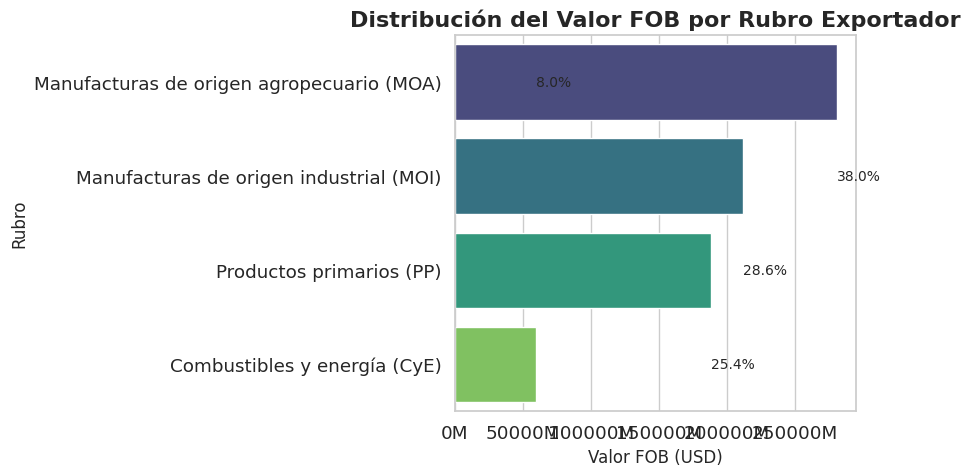

/tmp/ipython-input-3381205909.py:84: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


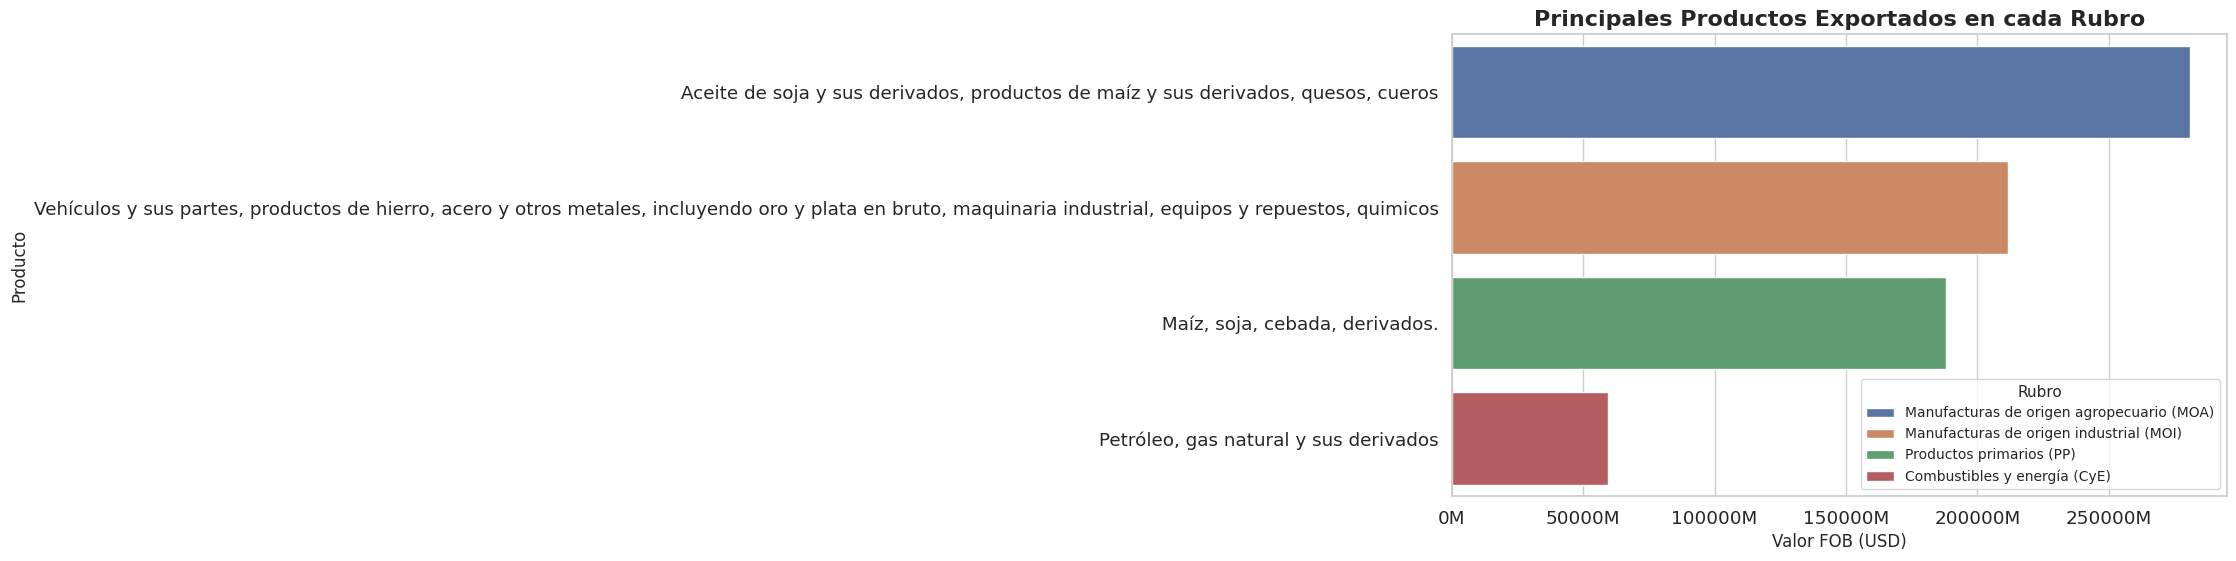

In [5]:

# --------------------------------
# EXPORTACIONES POR RUBRO Y PRODUCTO
# Formulación
# --------------------------------

df_rubro_producto = (
    df.groupby(['Rubro', 'tipo_Producto'])['FOB_dólar']
    .sum()
    .reset_index()
    .sort_values('FOB_dólar', ascending=False)
)

# --------------------------------
# Gráficas
# --------------------------------

df_top_rubros = (
    df.groupby('Rubro')['FOB_dólar']
    .sum()
    .reset_index()
    .sort_values('FOB_dólar', ascending=False)
)

total_fob = df_top_rubros['FOB_dólar'].sum()
df_top_rubros['Porcentaje'] = df_top_rubros['FOB_dólar'] / total_fob * 100

# Gráfico
plt.figure(figsize=(9,5))
sns.barplot(
    data=df_top_rubros,
    x='FOB_dólar',
    hue='Rubro',
    palette='viridis'
)

# Etiquetas de porcentaje
for i, row in df_top_rubros.iterrows():
    plt.text(
        row['FOB_dólar'],
        i,
        f"{row['Porcentaje']:.1f}%",
        va='center',
        fontsize=10
    )

plt.title('Distribución del Valor FOB por Rubro Exportador', fontsize=16, weight='bold')
plt.xlabel('Valor FOB (USD)', fontsize=12)
plt.ylabel('Rubro', fontsize=12)

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}M')
)

plt.tight_layout()
plt.show()

df_top_productos = (
    df.groupby(['Rubro', 'tipo_Producto'])['FOB_dólar']
    .sum()
    .reset_index()
    .sort_values('FOB_dólar', ascending=False)
    .groupby('Rubro')
    .head(2)
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=df_top_productos,
    x='FOB_dólar',
    hue='tipo_Producto',
    hue='Rubro',
    dodge=False
)

plt.title('Principales Productos Exportados en cada Rubro', fontsize=16, weight='bold')
plt.xlabel('Valor FOB (USD)', fontsize=12)
plt.ylabel('Producto', fontsize=12)

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.0f}M')
)

plt.legend=false
plt.tight_layout()
plt.show()

#####**Conclusión**

El análisis evidencia que las exportaciones argentinas durante el período estudiado se encuentran altamente concentradas en pocos rubros. Las Manufacturas de Origen Agropecuario (MOA) y las Manufacturas de Origen Industrial (MOI) explican la mayor parte del valor FOB total, seguidas a mayor distancia por los Productos Primarios y el sector de Combustibles y Energía.

Esta concentración se refuerza al analizar los productos específicos dentro de cada rubro. En el caso del sector agroindustrial, los derivados de la soja y del maíz concentran una proporción significativa del valor exportado, mientras que en el rubro industrial destacan productos vinculados a la metalurgia, la maquinaria y la industria automotriz.

En conjunto, los resultados muestran un perfil exportador especializado, donde un número reducido de rubros y productos actúan como principales generadores de divisas. Si bien esta especialización puede reflejar ventajas comparativas, también sugiere una exposición del comercio exterior argentino a variaciones en la demanda internacional y en los precios de estos productos clave.

In [6]:
#Formulas

# Variables

#*Ganancias*

## Ganancias de Exportacion por Año
ganancia_anio_rubro = df.groupby(['Rubro','Año'])['FOB_dólar'].sum()
ganancia_anio_region = df.groupby(['Nombre_Región','Año'])['FOB_dólar'].sum()
ganancia_anio_prov = df.groupby(['Nombre Prov','Año'])['FOB_dólar'].sum()

## Max Ganancias de Exportacion por Año
max_ganancia_anio_rubro = df.groupby(['Rubro','Año'])['FOB_dólar'].sum().idxmax()
max_ganancia_anio_region = df.groupby(['Nombre_Región','Año'])['FOB_dólar'].sum().idxmax()
max_ganancia_anio_prov = df.groupby(['Nombre Prov','Año'])['FOB_dólar'].sum().idxmax()

## Ganancias de Exportacion por Mes
ganancia_mes_rubro = df.groupby(['Rubro','Mes_nom'])['FOB_dólar'].sum()
ganancia_mes_region = df.groupby(['Nombre_Región','Mes_nom'])['FOB_dólar'].sum()
ganancia_mes_prov = df.groupby(['Nombre Prov','Mes_nom'])['FOB_dólar'].sum()

## Max Ganancias de Exportacion por Mes
max_ganancia_mes_rubro = df.groupby(['Rubro','Mes_nom'])['FOB_dólar'].sum().idxmax()
max_ganancia_mes_region = df.groupby(['Nombre_Región','Mes_nom'])['FOB_dólar'].sum().idxmax()
max_ganancia_mes_prov = df.groupby(['Nombre Prov','Mes_nom'])['FOB_dólar'].sum().idxmax()

## Promedio Ganancias de Exportacion por Año
prom_ganancia_anio_rubro = df.groupby(['Rubro','Año'])['FOB_dólar'].mean()
prom_ganancia_anio_region = df.groupby(['Nombre_Región','Año'])['FOB_dólar'].mean()
prom_ganancia_anio_prov = df.groupby(['Nombre Prov','Año'])['FOB_dólar'].mean()

## Promedio Ganancias de Exportacion por Mes
prom_ganancia_mes_rubro = df.groupby(['Rubro','Mes_nom'])['FOB_dólar'].mean()
prom_ganancia_mes_region = df.groupby(['Nombre_Región','Mes_nom'])['FOB_dólar'].mean()
prom_ganancia_mes_prov = df.groupby(['Nombre Prov','Mes_nom'])['FOB_dólar'].mean()

# *Cantidad/Peso*

## *Promedio Exportacion segun Cantidad/Peso por Año*
prom_exp_rubro_anio = df.groupby(['Rubro','Año'])['Peso neto'].mean()
prom_exp_region_anio = df.groupby(['Nombre_Región','Año'])['Peso neto'].mean()
prom_exp_prov_anio = df.groupby(['Nombre Prov','Año'])['Peso neto'].mean()

# *Maximos Exportacion segun Cantidad/Peso por Año*
max_exp_rubro_anio = df.groupby(['Rubro','Año'])['Peso neto'].sum().idxmax()
max_exp_region_anio = df.groupby(['Nombre_Región','Año'])['Peso neto'].sum().idxmax()
max_exp_prov_anio = df.groupby(['Nombre Prov','Año'])['Peso neto'].sum().idxmax()

## *Promedio Exportacion segun Cantidad/Peso por Mes*
prom_exp_rubro_mes = df.groupby(['Rubro','Mes_nom'])['Peso neto'].mean()
prom_exp_region_mes = df.groupby(['Nombre_Región','Mes_nom'])['Peso neto'].mean()
prom_exp_prov_mes = df.groupby(['Nombre Prov','Mes_nom'])['Peso neto'].mean()

# *Maximos Exportacion segun Cantidad/Peso por Mes*
max_exp_rubro_mes = df.groupby(['Rubro','Mes_nom'])['Peso neto'].sum().idxmax()
max_exp_region_mes = df.groupby(['Nombre_Región','Mes_nom'])['Peso neto'].sum().idxmax()
max_exp_prov_mes = df.groupby(['Nombre Prov','Mes_nom'])['Peso neto'].sum().idxmax()

# *Tops de Exportacion*

# Por Ganancia
top_ganancia_rubros = df.groupby('Rubro')['FOB_dólar'].sum().sort_values(ascending=False)
top_ganancia_region = df.groupby('Nombre_Región')['FOB_dólar'].sum().sort_values(ascending=False)
top_ganancia_prov = df.groupby('Nombre Prov')['FOB_dólar'].sum().sort_values(ascending=False)

# Por Cantidad
top_cant_exp_rubros = df.groupby('Rubro')['Peso neto'].sum().sort_values(ascending=False)
top_cant_exp_region = df.groupby('Nombre_Región')['Peso neto'].sum().sort_values(ascending=False)
top_cant_exp_prov = df.groupby('Nombre Prov')['Peso neto'].sum().sort_values(ascending=False)

# Por Año

# Por Ganancia
top_ganancia_rubros = df.groupby(['Rubro','Año'])['FOB_dólar'].sum().sort_values(ascending=False)
top_ganancia_region = df.groupby(['Nombre_Región','Año'])['FOB_dólar'].sum().sort_values(ascending=False)
top_ganancia_prov = df.groupby(['Nombre Prov','Año'])['FOB_dólar'].sum().sort_values(ascending=False)

# Por Cantidad
top_cant_exp_rubros = df.groupby(['Rubro','Año'])['Peso neto'].sum().sort_values(ascending=False)
top_cant_exp_region = df.groupby(['Nombre_Región','Año'])['Peso neto'].sum().sort_values(ascending=False)
top_cant_exp_prov = df.groupby(['Nombre Prov','Año'])['Peso neto'].sum().sort_values(ascending=False)

# Por Mes

# Por Ganancia
top_ganancia_rubros = df.groupby(['Rubro','Mes_nom'])['FOB_dólar'].sum().sort_values(ascending=False)
top_ganancia_region = df.groupby(['Nombre_Región','Mes_nom'])['FOB_dólar'].sum().sort_values(ascending=False)
top_ganancia_prov = df.groupby(['Nombre Prov','Mes_nom'])['FOB_dólar'].sum().sort_values(ascending=False)

# Por Cantidad
top_cant_exp_rubros = df.groupby(['Rubro','Mes_nom'])['Peso neto'].sum().sort_values(ascending=False)
top_cant_exp_region = df.groupby(['Nombre_Región','Mes_nom'])['Peso neto'].sum().sort_values(ascending=False)
top_cant_exp_prov = df.groupby(['Nombre Prov','Mes_nom'])['Peso neto'].sum().sort_values(ascending=False)

# **Por Rubro**

## Ganancias de Exportacion
ganancia_rubro_region = df.groupby(['Nombre_Región','Rubro'])['FOB_dólar'].sum()
ganancia_rubro_prov = df.groupby(['Nombre Prov','Rubro'])['FOB_dólar'].sum()

## Max Ganancias de Exportacion
max_ganancia_rubro_region = df.groupby(['Nombre_Región','Rubro'])['FOB_dólar'].sum().idxmax()
max_ganancia_rubro_prov = df.groupby(['Nombre Prov','Rubro'])['FOB_dólar'].sum().idxmax()

## Promedio Ganancias de Exportacion
prom_ganancia_rubro_region = df.groupby(['Nombre_Región','Rubro'])['FOB_dólar'].mean()
prom_ganancia_rubro_prov = df.groupby(['Nombre Prov','Rubro'])['FOB_dólar'].mean()

## *Promedio Exportacion segun Cantidad/Peso*
prom_exp_region_rubro = df.groupby(['Nombre_Región','Rubro'])['Peso neto'].mean()
prom_exp_prov_rubro = df.groupby(['Nombre Prov','Rubro'])['Peso neto'].mean()

# *Maximos Exportacion segun Cantidad/Peso*
max_exp_region_rubro = df.groupby(['Nombre_Región','Rubro'])['Peso neto'].sum().idxmax()
max_exp_prov_rubro = df.groupby(['Nombre Prov','Rubro'])['Peso neto'].sum().idxmax()

##Agregar promedios, agregar destinos
### Seccion de Rubro, Año, Ganancias (percents, means, max, tops)
## Grafico lineal por año, por rubro, barras horz por mes, barras ver ganancias,
# acumulado de rubro por año
### Seccion de regiones y stats (rubro, percents, means, max, tops)
## Dentro de cada region, stats por prov (rubro, percents, means, max, tops)
### Destinos y stats (rubro, percents, means, max, tops)
## Dentro de cada cont, stats por cont (rubro, percents, means, max, tops)

/tmp/ipython-input-619648794.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ganancia_mes_rubro = df.groupby(['Rubro','Mes_nom'])['FOB_dólar'].sum()
/tmp/ipython-input-619648794.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ganancia_mes_region = df.groupby(['Nombre_Región','Mes_nom'])['FOB_dólar'].sum()
/tmp/ipython-input-619648794.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ganancia_mes_prov = df.gr

/tmp/ipython-input-2122702020.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_anio, x="Año", y="FOB_dólar", palette="Blues")



Al Año

Año con más Exportaciones: ('Productos primarios (PP)', np.int64(2021)) 
Productos Exportados  Maíz, soja, cebada, derivados.

 Total de Ganancias >>  33.17 Mil millones

Al Mes

Mes con más Exportaciones:  ('Productos primarios (PP)', 'May') 
 Cantidad Exportada >>  61577.37 Tn.

Total de Ganancias: 33.17 Mil millones


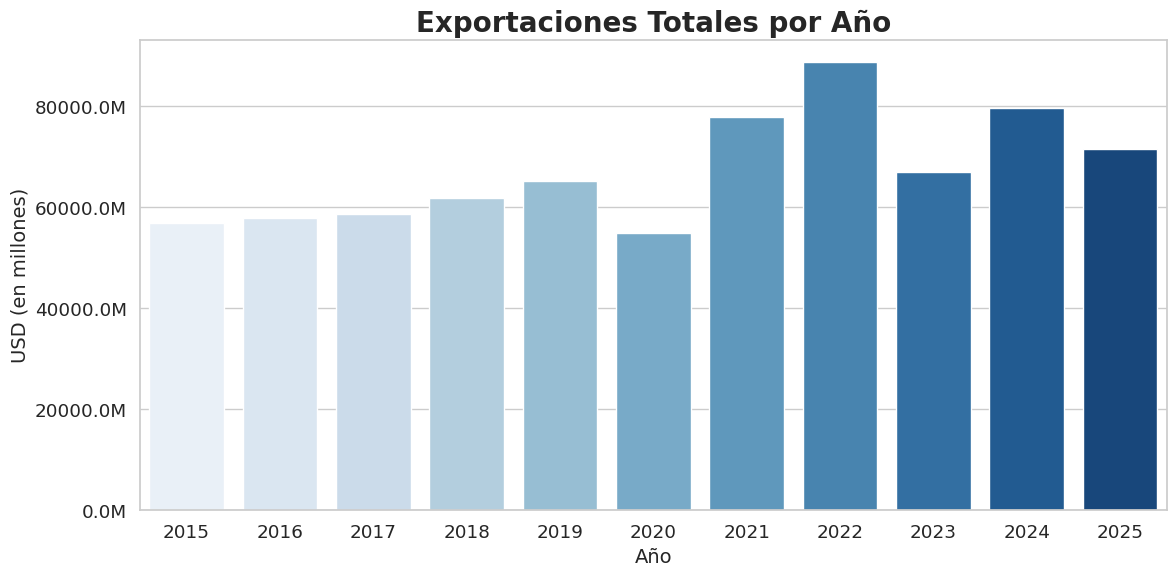

/tmp/ipython-input-2122702020.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rubro.head(10), x="FOB_dólar", y="Rubro", palette="crest")


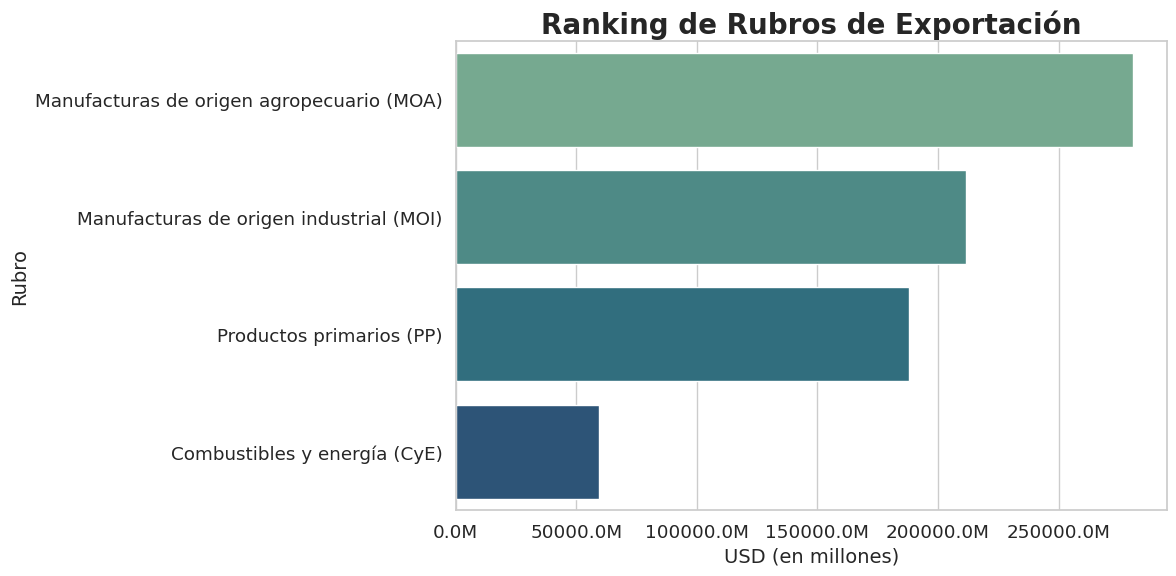

NameError: name 'px' is not defined

In [7]:

#**Seccion I**
#Análisis por Rubro

#mes_max_exp = df.groupby(['Rubro','Mes']). size().idxmax()

max_ganancia_anio = df.groupby(['Rubro','Año'])['FOB_dólar'].sum().max()

print("\nAl Año\n")
print("Año con más Exportaciones:", max_exp_rubro_anio,
      "\nProductos Exportados", df.groupby(['Peso neto','Año'])['tipo_Producto'].sum().max())
print("\n Total de Ganancias >> ", formato_millones(max_ganancia_anio))

peso_mes = df.groupby(['tipo_Producto','Mes'])['Peso neto'].sum().max()
max_ganancia_mes = df.groupby(['Rubro','Mes'])['FOB_dólar'].sum().max()

print("\nAl Mes\n")
print("Mes con más Exportaciones: ", max_exp_rubro_mes,
      "\n Cantidad Exportada >> ", peso_legible(peso_mes))
print("\nTotal de Ganancias:", formato_millones(max_ganancia_anio))


##Graficos

df_anio = df.groupby("Año")["FOB_dólar"].sum().reset_index()

plt.figure()
sns.barplot(data=df_anio, x="Año", y="FOB_dólar", palette="Blues")
plt.title("Exportaciones Totales por Año")
plt.ylabel("USD (en millones)")
plt.xlabel("Año")
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}M")
)
plt.tight_layout()
plt.show()

df_rubro = df.groupby("Rubro")["FOB_dólar"].sum().reset_index().sort_values("FOB_dólar", ascending=False)

plt.figure()
sns.barplot(data=df_rubro.head(10), x="FOB_dólar", y="Rubro", palette="crest")
plt.title("Ranking de Rubros de Exportación")
plt.xlabel("USD (en millones)")
plt.ylabel("Rubro")
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f"{x/1_000_000:.1f}M")
)
plt.tight_layout()
plt.show()

#Exportacion por año Lineal

#exp_anio_lineal = df.pivot_table(values='FOB_dólar', index='Año', columns='Rubro', aggfunc='sum')
#exp_anio_lineal.plot(kind='line', figsize=(12,6))

#Cantidad Exportaciones por mes Barras

#fig, ax = plt.subplots(figsize=(10,5))sns.barplot(data=df, x="Mes_nom", y="FOB_dólar", ax=ax)

#ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M"))

#plt.title("Ganancias mensuales en millones de USD", fontsize=18)
#plt.tight_layout()
#plt.show()

#Ganancias por Mes

#ganancia_mes_lineal = df.pivot_table(values='FOB_dólar', index='Mes', columns='Rubro', aggfunc='sum')
#ganancia_mes_lineal.plot(kind='line', figsize=(12,6))

#Rubros Exportados

fig = px.treemap(df, path=['Rubro'], values = "FOB_dólar", color = "FOB_dólar")
fig.update_layout(width=800, height=600)
fig.update_layout(title='Productos Exportados', xaxis_title='Eje X', yaxis_title='Eje Y')
plt.figure(figsize=(10,5))
plt.show()
fig.show()




In [ ]:
#**Seccion II**
#Análisis por Region

#Rubro mas exportado por Region

rubro_mas_exp_region = df.groupby(['Nombre_Región','Rubro'])['FOB_dólar'].sum().idxmax()
mean_exp_region = df.groupby(['Nombre_Región','Rubro'])['FOB_dólar'].mean()
anio_max_exp_region = df.groupby(['Nombre_Región','Año'])['FOB_dólar'].sum().idxmax()
mes_max_exp_region = df.groupby(['Nombre_Región','Mes'])['FOB_dólar'].sum().idxmax()
region_max_exp_region = df.groupby(['Nombre_Región'])['FOB_dólar'].sum().idxmax()


print("Rubro más exportado:", rubro_mas_exp_region,"\n")
#print("\nPromedio Exportacion por Region:", mean_exp_region)
print("\nAño con más Exportaciones por Region:", anio_max_exp_region)
print("\nMes con más Exportaciones por Region:", mes_max_exp_region)
print("\nRegion más Exportadora:", region_max_exp_region)
